In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# Open up PRC csv
filename_1= '../EDCOM/MCA_JOBLIST_COMBINED.csv'
prc_df = pd.read_csv(filename_1)
prc_df['Job Title'] = prc_df['Job Title'].str.strip()

# Open up EDCOM csv
filename_1= '../EDCOM/MCA Job List Tagged FINAL.csv'
edcom_df = pd.read_csv(filename_1)
edcom_df['Job Title'] = edcom_df['Job Title'].str.strip()

# Open up WorldBank csv
filename_2 = '../WorldBank/final_mca_aioe_comple.csv'
worldbank_df = pd.read_csv(filename_2)

# Combine the PRC and EDCOM and then with WorldBank
overall_edcom_df = edcom_df.merge(prc_df, on='Job Title')
combined_df = overall_edcom_df.merge(worldbank_df, on='Job Title')
passers_filt = combined_df['passers_2023_agg'].notna()

# These exclude_jobs should never have been a priority sector job
exclude_jobs = [
    "Events Assistant",
    "Facilities Management Assistant",
    "Park and Garden Rangers",
    "Public Attendant / Public Area Cleaner",
    "Security Guard",
    "Security Operations Staff",
    "Surveillance Officer (CCTV Operation)"
]

combined_df.loc[
    combined_df['Job Title'].isin(exclude_jobs),
    ["Priority Sector", "Priority Sector (Y/N)_x"]
] = "N"

# Keep relevant columns
relevant_cols = [
    "Job Title",
    "Job Sector",
    "Job Subsector",
    "Educational Pathway",
    "HEI with PRC (Professional Regulation Commission) Exam",
    "Some HEI",
    "Priority Sector (Y/N)_x",
    "Priority Sector",
    "passers_2023_agg",
    "examinees_2023_agg", 
    "passers_2024_agg",
    "examinees_2024_agg",
    'SOC',
    "AIOE",
    "Complementarity",
    "C-AIOE",
    "Classification"
]

combined_df = combined_df[relevant_cols]


# Rename a certain column
combined_df.rename(
    columns={'Priority Sector (Y/N)_x':'Priority Sector (Y/N)'}, 
    inplace=True
)

combined_df.to_csv('../final_mca_aioe_comple.csv', index=False)

In [13]:
combined_df['Job Sector'].value_counts()

Job Sector
Manufacturing                                                           157
Human Health and Social Work Activities                                 139
Professional, Scientific and Technical Activities                       135
Information and Communication                                           105
Construction                                                             99
Agriculture, Forestry, and Fishing                                       88
Arts, Entertainment and Recreation                                       74
Accommodation and Food Service Activities                                67
Transportation and Storage                                               57
Education                                                                52
Administrative and Support Service Activities                            45
Public Administration and Defense; Compulsory Social Security            33
Financial and Insurance Activities                                       30
E

In [63]:
is_prio = combined_df['Priority Sector'] != "N"
is_edu = combined_df['Educational Pathway'] == "Higher Education"

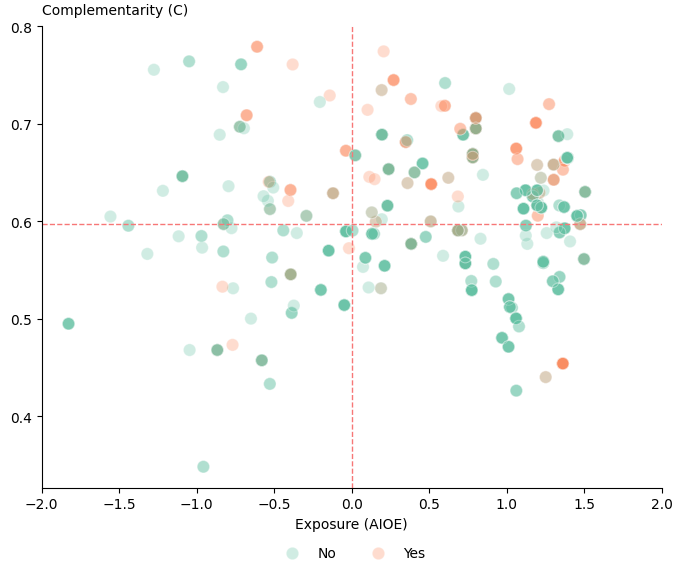

In [64]:
plt.figure(figsize=(8, 6))

is_prio = combined_df['Priority Sector'] != "N"

sns.scatterplot(
    data=combined_df[is_edu],
    x='AIOE',
    y='Complementarity',
    hue='HEI with PRC (Professional Regulation Commission) Exam',
    palette='Set2',
    alpha=0.3,
    s=80
)

# Representative jobs (manually chosen)
rep_jobs = {
    "Protected":  {"idx": 822, "title": "Police Officer"},
    "Isolated":  {"idx": 239, "title": "Cook"},
    "Augmentable": {"idx": 349, "title": "English Subject Teacher"},
    "Displaced": {"idx": 283, "title": "Data Scientist"}
}


plt.legend(
    loc="upper center",       # place above or below plot
    bbox_to_anchor=(0.5, -0.1), # shift below the axes
    ncol=2,                   # number of columns
    frameon=False             # remove legend box outline
)

# Axes limits and lines
plt.xlim(-2, 2)
#plt.ylim(-3, 3)
plt.axvline(x=0, color="#f77777", linestyle='--', linewidth=1)
plt.axhline(y=combined_df['Complementarity'].median(), color='#f77777', linestyle='--', linewidth=1)

# Labels
plt.xlabel('Exposure (AIOE)')
plt.ylabel('Complementarity (C)', rotation=0, ha='left')
plt.gca().yaxis.set_label_coords(0, 1.02)

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Title
#plt.title('AIOE to Complementarity for Filipino Jobs by Educational Pathway\n\n')

plt.show()

In [ ]:
is_prc = combined_df['HEI with PRC (Professional Regulation Commission) Exam'] == 'Yes'
is_higher_ed = combined_df['HEI with PRC (Professional Regulation Commission) Exam'] == 'Yes'
passers_df = combined_df[~is_prc].groupby('Classification')['passers_2024_agg'].sum().sort_values(ascending=True)
norm_passers_df = (passers_df / passers_df.sum())
norm_passers_df.plot(kind='barh', color='coral')
plt.ylabel('')
plt.xlabel('Proportion of Newly Licensed Workers in 2024')

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#plt.title('Proportion of of Newly Licensed\nWorkers in 2024 to Job Classification\n\n')

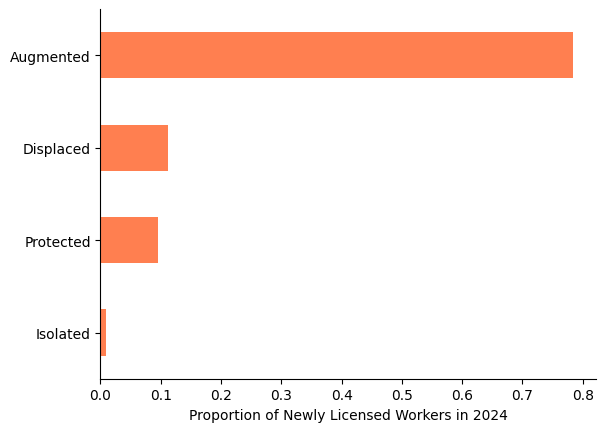

In [58]:
is_prc = combined_df['HEI with PRC (Professional Regulation Commission) Exam'] == 'Yes'
passers_df = combined_df[is_prc].groupby('Classification')['passers_2024_agg'].sum().sort_values(ascending=True)
norm_passers_df = (passers_df / passers_df.sum())
norm_passers_df.plot(kind='barh', color='coral')
plt.ylabel('')
plt.xlabel('Proportion of Newly Licensed Workers in 2024')

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#plt.title('Proportion of of Newly Licensed\nWorkers in 2024 to Job Classification\n\n')

In [45]:
is_higher_ed = combined_df['Educational Pathway'] == 'Higher Education'
is_prc = combined_df['HEI with PRC (Professional Regulation Commission) Exam'] == 'Yes'
#combined_df[is_higher_ed]
print('Without PRC')
combined_df[is_higher_ed & ~is_prc].groupby("Priority Sector")[['AIOE', 'Complementarity', 'C-AIOE']].median()
combined_df[is_higher_ed & ~is_prc]

Without PRC


,Job Title,Job Sector,Job Subsector,Educational Pathway,HEI with PRC (Professional Regulation Commission) Exam,Some HEI,Priority Sector (Y/N),Priority Sector,passers_2023_agg,examinees_2023_agg,passers_2024_agg,examinees_2024_agg,SOC,AIOE,Complementarity,C-AIOE,Classification
0,2D Echocardiography Technician,Human Health and Social Work Activities,Medical and dental practice activities,Higher Education,No,Yes,Y,Health,NaN,NaN,NaN,NaN,29-2035,-0.120708,0.628889,-0.086843,Protected
4,3D Printing Designer,Manufacturing,Manufacture of other fabricated metal products...,Higher Education,No,No,Y,Digital Technology,NaN,NaN,NaN,NaN,27-1024,0.733024,0.563889,0.575017,Displaced
8,Academic Researcher,"Professional, Scientific and Technical Activities",Research and experimental development on socia...,Higher Education,No,No,N,N,NaN,NaN,NaN,NaN,19-1099,1.196276,0.616494,0.875482,Augmented
9,Accounting Clerk (Healthcare),Human Health and Social Work Activities,Hospital activities,Higher Education,No,Yes,Y,Health,NaN,NaN,NaN,NaN,43-3031,1.020493,0.512222,0.853246,Displaced
11,Accounting Staff (Construction),Construction,Construction of buildings,Higher Education,No,No,Tourism,Tourism,NaN,NaN,NaN,NaN,43-3031,1.020493,0.512222,0.853246,Displaced
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1144,Wildlife Field Assistant,"Professional, Scientific and Technical Activities","Other professional, scientific and technical a...",Higher Education,No,Yes,N,N,NaN,NaN,NaN,NaN,31-9096,-0.826582,0.597222,-0.620855,Protected
1146,Window Cleaner,Accommodation and Food Service Activities,Other accommodation,Higher Education,No,No,Tourism,Tourism,NaN,NaN,NaN,NaN,47-4071,-1.218287,0.631389,-0.873444,Protected
1148,Workforce Management Analyst,Administrative and Support Service Activities,"Business support service activities, n.e.c.",Higher Education,No,No,Y,Financial Services,NaN,NaN,NaN,NaN,13-1151,1.196646,0.631944,0.857264,Augmented
1149,Workforce Wellness Coordinator,Human Health and Social Work Activities,Other social work activities without accommoda...,Higher Education,No,Yes,Y,Health,NaN,NaN,NaN,NaN,29-9092,1.505670,0.630278,1.081154,Augmented


In [46]:
print('With PRC')
combined_df[is_higher_ed & is_prc].groupby("Priority Sector")[['AIOE', 'Complementarity', 'C-AIOE']].median()
combined_df[is_higher_ed & is_prc]

With PRC


,Job Title,Job Sector,Job Subsector,Educational Pathway,HEI with PRC (Professional Regulation Commission) Exam,Some HEI,Priority Sector (Y/N),Priority Sector,passers_2023_agg,examinees_2023_agg,passers_2024_agg,examinees_2024_agg,SOC,AIOE,Complementarity,C-AIOE,Classification
10,Accounting Professional (Manufacturing),Manufacturing,"Other manufacturing, n.e.c.",Higher Education,Yes,No,N,N,2740.0,8734.0,3058.0,10136.0,13-2082,1.362074,0.454167,1.217921,Displaced
21,Agricultural Engineer,"Agriculture, Forestry, and Fishing",Support activities to agriculture and post-har...,Higher Education,Yes,No,N,N,615.0,1841.0,1479.0,2625.0,17-2141,1.167378,0.628056,0.840836,Augmented
22,Agricultural Extension Officer,"Agriculture, Forestry, and Fishing",Support activities to agriculture and post-har...,Higher Education,Yes,No,N,N,615.0,1841.0,1479.0,2625.0,19-4071,-0.677779,0.708889,-0.433402,Protected
23,Agricultural Lab Technician,"Professional, Scientific and Technical Activities",Research and experimental development on natur...,Higher Education,Yes,No,N,N,3423.0,10014.0,3628.0,7144.0,19-4011,1.196276,0.616494,0.875482,Augmented
27,Agricultural Specialist,"Agriculture, Forestry, and Fishing",Support activities to agriculture and post-har...,Higher Education,Yes,No,N,N,615.0,1841.0,1479.0,2625.0,25-9021,0.800655,0.706111,0.514199,Augmented
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,Urban Forestry Aide,"Agriculture, Forestry, and Fishing",Silviculture and other forestry activities,Higher Education,Yes,No,N,N,1076.0,1947.0,928.0,1574.0,25-9021,0.800655,0.706111,0.514199,Augmented
1105,Values Education Teacher,Education,"Primary/elementary education, Secondary/high s...",Higher Education,Yes,No,N,N,77777.0,146562.0,68900.0,129928.0,25-2022,1.273166,0.720278,0.799619,Augmented
1118,Voice and Speech Therapist,Human Health and Social Work Activities,Medical and dental practice activities,Higher Education,Yes,No,Y,Health,323.0,554.0,353.0,536.0,29-1181,0.700121,0.695000,0.457412,Augmented
1131,Wastewater Treatment Specialist,"Water Supply; Sewerage, Waste Management and R...",Waste treatment and disposal,Higher Education,Yes,No,Tourism,Tourism,76.0,162.0,105.0,156.0,51-8031,-0.535494,0.640556,-0.379011,Protected


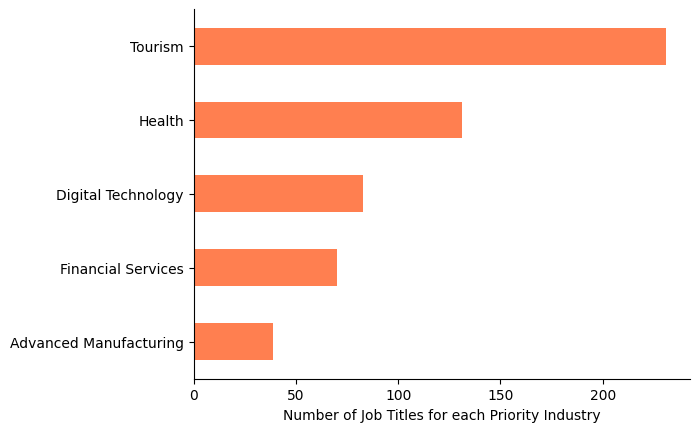

In [27]:
combined_df[combined_df['Priority Sector'] != 'N'] \
    .groupby('Priority Sector')['Job Title'] \
    .count() \
    .sort_values() \
    .plot(kind='barh', color='coral')

plt.ylabel('')
plt.xlabel('Number of Job Titles for each Priority Industry')

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#plt.title('Proportion of of Newly Licensed\nWorkers in 2024 to Job Classification\n\n')

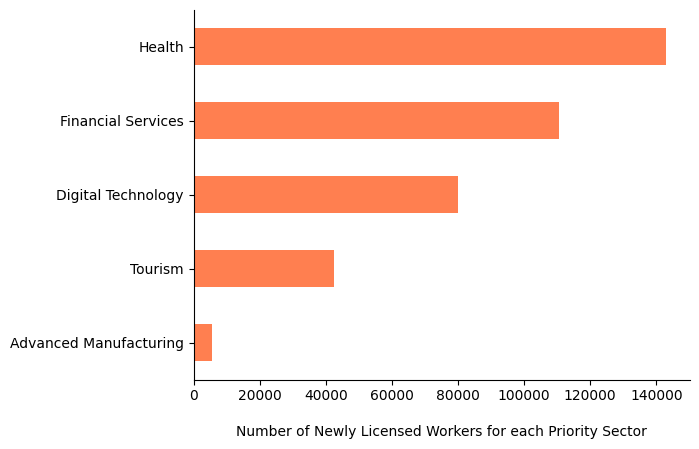

In [18]:
combined_df[combined_df['Priority Sector'] != 'N'] \
    .groupby('Priority Sector')['passers_2023_agg'] \
    .sum() \
    .sort_values() \
    .plot(kind='barh', color='coral')

plt.ylabel('')
plt.xlabel('\nNumber of Newly Licensed Workers for each Priority Sector')

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

#plt.title('Proportion of of Newly Licensed\nWorkers in 2024 to Job Classification\n\n')

In [16]:
combined_df.groupby('Educational Pathway')[['AIOE', 'Complementarity','C-AIOE']].median()

,AIOE,Complementarity,C-AIOE
Educational Pathway,,,
Higher Education,0.780637,0.605833,0.575017
Not Higher Education,-0.768875,0.576944,-0.595790


In [ ]:
combined_df['Educational Pathway'].group

0           Higher Education
1       Not Higher Education
2       Not Higher Education
3       Not Higher Education
4           Higher Education
                ...         
1146        Higher Education
1147    Not Higher Education
1148        Higher Education
1149        Higher Education
1150        Higher Education
Name: Educational Pathway, Length: 1151, dtype: object

In [8]:
combined_df['Priority Sector'].value_counts()

Priority Sector
N                         597
Tourism                   231
Health                    131
Digital Technology         83
Financial Services         70
Advanced Manufacturing     39
Name: count, dtype: int64

In [5]:
combined_df.query("`Priority Sector` == 'Digital Technology' and `HEI with PRC (Professional Regulation Commission) Exam` == 'Yes'")

,Job Title,Job Sector,Job Subsector,Educational Pathway,HEI with PRC (Professional Regulation Commission) Exam,Some HEI,Priority Sector (Y/N),Priority Sector,passers_2023_agg,examinees_2023_agg,passers_2024_agg,examinees_2024_agg,SOC,AIOE,Complementarity,C-AIOE,Classification
715,Mechatronics Engineer,"Professional, Scientific and Technical Activities",Architectural and engineering activities and r...,Higher Education,Yes,No,Y,Digital Technology,2133.0,4237.0,1144.0,3485.0,17-2141,1.167378,0.628056,0.840836,Augmented
716,Media Arts Teaching Assistant,Education,Other education services,Higher Education,Yes,No,Y,Digital Technology,77777.0,146562.0,68900.0,129928.0,27-4099,0.733024,0.556926,0.580120,Displaced


In [75]:
combined_df['Priority Sector'].value_counts()

Priority Sector
N                         597
Tourism                   231
Health                    131
Digital Technology         83
Financial Services         70
Advanced Manufacturing     39
Name: count, dtype: int64

In [100]:
is_priority = (combined_df['Priority Sector'] != "N")
is_prc = ~combined_df['passers_2023_agg'].isnull()

combined_df.loc[is_priority & is_prc].groupby("Priority Sector").agg({
    "Job Title": "count", # count for 2024
    "passers_2024_agg": "sum",    # sum for 2024
    "C-AIOE": "median"             # median risk index
}).round(4)

,Job Title,passers_2024_agg,C-AIOE
Priority Sector,,,
Advanced Manufacturing,5,5140.0,0.5193
Digital Technology,2,70044.0,0.7105
Financial Services,13,105596.0,1.2179
Health,35,171950.0,0.1653
Tourism,11,45795.0,0.3642


In [99]:
combined_df.loc[is_priority].groupby('Priority Sector')['Educational Pathway'].value_counts()

Priority Sector         Educational Pathway 
Advanced Manufacturing  Not Higher Education     20
                        Higher Education         19
Digital Technology      Higher Education         58
                        Not Higher Education     25
Financial Services      Higher Education         62
                        Not Higher Education      8
Health                  Higher Education         95
                        Not Higher Education     36
Tourism                 Not Higher Education    133
                        Higher Education         98
Name: count, dtype: int64

In [98]:
combined_df.groupby('Educational Pathway')['Classification'].value_counts(normalize=True)

Educational Pathway   Classification
Higher Education      Augmented         0.457604
                      Displaced         0.335128
                      Isolated          0.119785
                      Protected         0.087483
Not Higher Education  Isolated          0.421569
                      Protected         0.355392
                      Displaced         0.147059
                      Augmented         0.075980
Name: proportion, dtype: float64

In [110]:
combined_df[combined_df['Priority Sector'] == 'Tourism'].groupby('Job Sector')['C-AIOE'].count()

Job Sector
Accommodation and Food Service Activities                   67
Construction                                                99
Transportation and Storage                                  58
Water Supply; Sewerage, Waste Management and Remediation     7
Name: C-AIOE, dtype: int64

In [104]:
combined_df[combined_df['Priority Sector'] == 'Tourism']['Job Sector'].value_counts(normalize=True)

Job Sector
Construction                                                0.428571
Accommodation and Food Service Activities                   0.290043
Transportation and Storage                                  0.251082
Water Supply; Sewerage, Waste Management and Remediation    0.030303
Name: proportion, dtype: float64

In [92]:
is_priority = (combined_df['Priority Sector'] != "N")
is_prc = ~combined_df['passers_2023_agg'].isnull()

combined_df.loc[is_priority].groupby("Priority Sector").agg({
    "Job Title": "count", # count for 2024
    "passers_2023_agg": "sum"
})

,Job Title,passers_2023_agg
Priority Sector,,
Advanced Manufacturing,39,5501.0
Digital Technology,83,79910.0
Financial Services,70,110657.0
Health,131,142960.0
Tourism,231,42444.0


In [20]:
combined_df[combined_df['Priority Sector'] != 'N'].groupby("Priority Sector").agg({
    "passers_2024_agg": "sum", # count for 2024
    "C-AIOE": "median"             # median risk index
}).round(4)

,passers_2024_agg,C-AIOE
Priority Sector,,
Advanced Manufacturing,5140.0,-0.0282
Digital Technology,70044.0,0.9758
Financial Services,105596.0,0.9499
Health,171950.0,0.1630
Tourism,45795.0,-0.4192


In [26]:
filt = combined_df['Priority Sector'] == 'Tourism'
combined_df[filt].groupby("Job Sector").agg({
    "Job Title": "count",
    "passers_2024_agg": "sum", # count for 2024
    "C-AIOE": "median"             # median risk index
}).round(4)

,Job Title,passers_2024_agg,C-AIOE
Job Sector,,,
Accommodation and Food Service Activities,67,6835.0,-0.3344
Construction,99,28857.0,-0.6970
Transportation and Storage,58,9893.0,-0.3105
"Water Supply; Sewerage, Waste Management and Remediation",7,210.0,0.8033


In [35]:
df_counts = combined_df[passers_filt].groupby('Classification')[['passers_2023_agg', 'passers_2024_agg']].sum() 

df_counts['average'] = df_counts['passers_2023_agg'] + df_counts['passers_2024_agg']
df_counts_normalized = df_counts / df_counts.sum()
df_counts_normalized.round(2)


,passers_2023_agg,passers_2024_agg,average
Classification,,,
Augmented,0.79,0.78,0.79
Displaced,0.11,0.11,0.11
Isolated,0.01,0.01,0.01
Protected,0.10,0.10,0.10


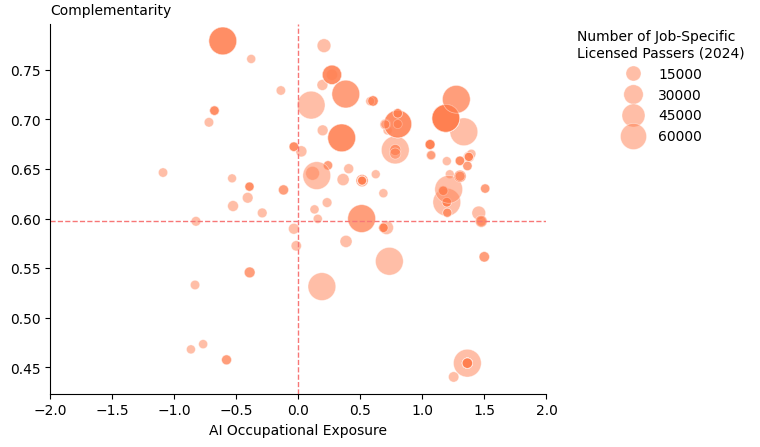

In [25]:
sns.scatterplot(
    x="AIOE", 
    y="Complementarity", 
    size="passers_2024_agg",
    sizes=(40, 400),
    alpha=0.5,
    data=combined_df[passers_filt],
    color='coral'
)

plt.axvline(x=0, color="#f77777", linestyle='--', linewidth=1)
plt.axhline(
    y=combined_df['Complementarity'].median(),
    color='#f77777', linestyle='--', linewidth=1
)

plt.ylabel('Complementarity', ha='left', rotation=0)
plt.xlabel('AI Occupational Exposure')
plt.gca().yaxis.set_label_coords(0, 1.02)
plt.xlim(-2, 2)

# --- move legend outside on the right & rename title ---
legend = plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    frameon=False,
    title="Number of Job-Specific\nLicensed Passers (2024)"
)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

In [21]:
normalized_licensed = (
    combined_df[passers_filt]
    .groupby('Classification')['passers_2024_agg']
    .sum()
)

normalized_licensed = normalized_licensed / normalized_licensed.sum()
normalized_licensed

Classification
Augmented    0.783556
Displaced    0.111962
Isolated     0.008454
Protected    0.096028
Name: passers_2024_agg, dtype: float64

In [117]:
normalized_licensed = (
    combined_df[passers_filt & (combined_df['Priority Sector'] == 'Health')]
    .groupby('Classification')['passers_2024_agg']
    .sum()
)

normalized_licensed = normalized_licensed / normalized_licensed.sum()
normalized_licensed

Classification
Augmented    0.824984
Displaced    0.017784
Isolated     0.084449
Protected    0.072783
Name: passers_2024_agg, dtype: float64

Text(0, 0.5, '')

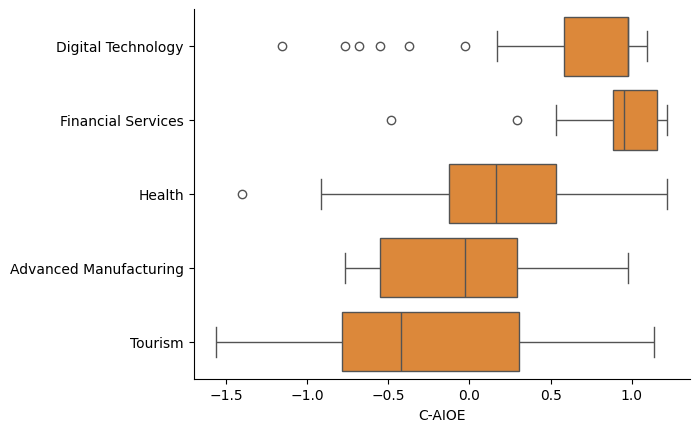

In [7]:
order = (
    combined_df.loc[combined_df["Priority Sector"] != "N"]
    .groupby("Priority Sector")["C-AIOE"]
    .median()
    .sort_values(ascending=False)
    .index
)

#plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=combined_df.loc[combined_df["Priority Sector"] != "N"],
    y='Priority Sector',
    x='C-AIOE',
    order=order,
    color='#f7871f'
)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.ylabel('')

In [36]:
(
    combined_df.loc[combined_df["Priority Sector"] != "N"]
    .groupby("Priority Sector")["C-AIOE"]
    .median()
    .sort_values(ascending=False)
)

Priority Sector
Digital Technology        0.975802
Financial Services        0.949893
Health                    0.162954
Advanced Manufacturing   -0.028245
Tourism                  -0.419217
Name: C-AIOE, dtype: float64

Text(0, 0.5, '')

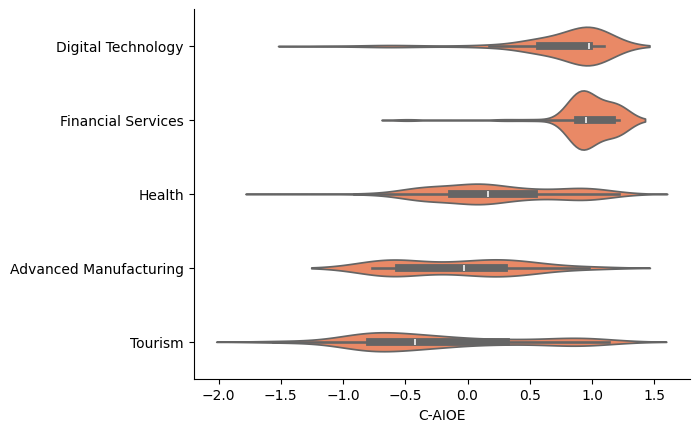

In [8]:
sns.violinplot(
    data=combined_df.loc[combined_df["Priority Sector"] != "N"],
    y='Priority Sector',
    x='C-AIOE',
    order=order,
    color='coral'
    #inner="quartile"  # optional, shows quartiles inside the violin
)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.ylabel('')


<Axes: >

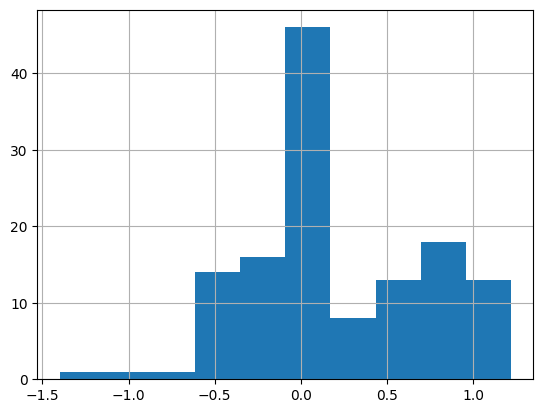

In [16]:
filt = combined_df['Priority Sector'] == 'Health'
combined_df.loc[filt, 'C-AIOE'].hist()

In [179]:
combined_df.to_csv('../MCA_Job_List_EDCOM_WorldBank.csv')